In [13]:
import sys
sys.path.append("../")

from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from aqua.plotting_functions import *
from aqua.utils import *

from functions import *


In [ ]:
T = 100 * ms

# autapse parameters (for the reference neuron)
e = 0.2*kHz
f = 250.0 * pA
tau = 0.0 * ms
net_charge = f/e
print(f"NET CURRENT: {net_charge}")
print(f"DEFAULT CLOCK: {defaultclock.dt}")

# the autapse time range
t_min = tau
t_max = 50*ms
d_t = (t_max - t_min)
print(f"D_T: {d_t}")
n_steps = d_t/defaultclock.dt   # number of timesteps
d_w = net_charge / d_t          # current per step
print(f"N STEPS: {n_steps}")
print(f"D_W: {d_w}")

# biexponential parameters
t_a1 = 1*ms
t_a2 = 1/e
I_peak = (net_charge / (t_a2 - t_a1)) * ((t_a1/t_a2)**(t_a1/(t_a2 - t_a1)) - (t_a1/t_a2)**(t_a2/(t_a2 - t_a1)))
print(f"I PEAK: {I_peak}") 

P = SpikeGeneratorGroup(1, [0], [10*ms])

## Uniform autapse current!
target = NeuronGroup(1, 'w : amp', method='euler')
target.w = 0.

syn = Synapses(P, target,
               on_pre={'start': 'w += d_w', 
                       'stop':  'w -= d_w'})

syn.connect()
syn.start.delay = t_min
syn.stop.delay = t_max


## Monoexponential autapse current
autapse = NeuronGroup(1,
        '''
        dw/dt = (-e_a*w) : amp
        e_a : Hz
        ''',
        method = 'rk2')
autapse.e_a = e     # set the decay constant

syn_aut = Synapses(P, autapse,
                   on_pre='w += f')
syn_aut.connect()
syn_aut.delay = tau     # set the synaptic delay


## Biexponential autapse current
biexp = NeuronGroup(1,
        '''
        dw/dt = ((t_a2 / t_a1) ** (t_a1 / (t_a2 - t_a1))*x-w)/t_a1 : amp
        dx/dt = -x/t_a2 : amp
        t_a1 : second
        t_a2 : second
        ''',
        method = 'rk2')
biexp.t_a2 = t_a2     # set the decay constant
biexp.t_a1 = t_a1
syn_biexp = Synapses(P, biexp,
                   on_pre='x += I_peak')
syn_biexp.connect()
syn_biexp.delay = tau     # set the synaptic delay


mon_p = SpikeMonitor(P)
mon_target = StateMonitor(target, 'w', record = True)
mon_aut = StateMonitor(autapse, 'w', record = True)
mon_biexp = StateMonitor(biexp, ['w', 'x'], record = True)

run(T)


NET CURRENT: 1.25 pC
DEFAULT CLOCK: 100. us
D_T: 50. ms
N STEPS: 500.0
D_W: 25. pA
I PEAK: 167.18507624 pA


[10.] ms
NET CURRENT: 1.25 pC
CURRENT AUTAPSE: 1.26262624 pC
CURRENT AUTAPSE: 1.24933544 pC
CURRENT STEP: 1.25 pC


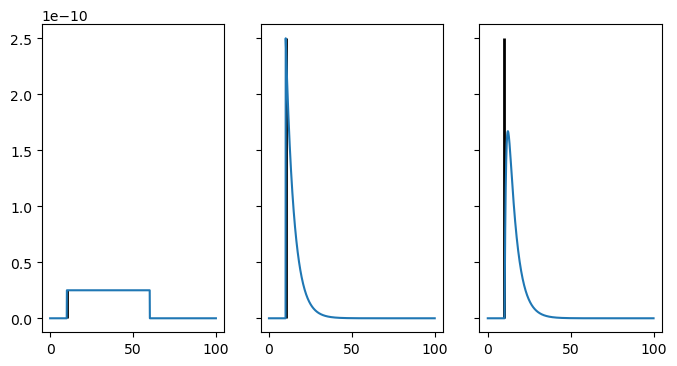

In [15]:
fig, ax = plt.subplots(1, 3, figsize = (8, 4), sharey = True)

spikes = mon_p.spike_trains()[0]
print(spikes)

ax[0].vlines(spikes/ms, ymin = 0, ymax = d_w, color = 'black', linewidth = 2.)
ax[0].plot(mon_target.t/ms, mon_target.w[0])

ax[1].vlines(spikes/ms, ymin = 0, ymax = f, color = 'black', linewidth = 2.)
ax[1].plot(mon_aut.t/ms, mon_aut.w[0])

ax[2].vlines(spikes/ms, ymin = 0, ymax = f, color = 'black', linewidth = 2.)
ax[2].plot(mon_biexp.t/ms, mon_biexp.w[0])

print(f"NET CURRENT: {net_charge}")
print(f"CURRENT AUTAPSE: {np.sum(mon_aut.w[0]) * defaultclock.dt}")
print(f"CURRENT AUTAPSE: {np.sum(mon_biexp.w[0]) * defaultclock.dt}")
print(f"CURRENT STEP: {np.sum(mon_target.w[0])* defaultclock.dt}")
